In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree

from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import precision_score, recall_score, f1_score, confusion_matrix, roc_curve, roc_auc_score


df=pd.read_csv('D:/Data Science/Assignment 5/WA_Fn-UseC_-Telco-Customer-Churn.csv')

## Part 1: Data Preprocessing and Feature Engineering

In [5]:
pd.set_option('display.max_columns', None)
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df.shape

(7043, 21)

In [9]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [10]:
#converting total charges to numeric
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [12]:
#dropping the rows with missing total charges
df = df.dropna()

In [13]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [14]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


In [15]:
df['Churn'].value_counts()

Churn
No     5163
Yes    1869
Name: count, dtype: int64

In [16]:
#encoding the target variable churn
df.loc[:, 'Churn'] = df['Churn'].map({'Yes': 1, 'No': 0})

In [17]:
df['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [18]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [22]:
df.loc[:, 'Churn'] = df['Churn'].astype(int)

In [23]:
df

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,0
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,0
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,1
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,0
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,0
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,0
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,0
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,1


In [24]:
#separating features and target
X = df.drop(['customerID', 'Churn'], axis=1) #independent variable
y = df['Churn'] #target variable

In [25]:
y

0       0
1       0
2       1
3       0
4       1
       ..
7038    0
7039    0
7040    0
7041    1
7042    0
Name: Churn, Length: 7032, dtype: int64

In [26]:
#one hot encoding of categorical variables
X = pd.get_dummies(X, drop_first=True) #dropping the first category to prevent multicollinearity

In [27]:
X

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,0,24,84.80,1990.50,True,True,True,True,False,True,False,False,False,True,False,False,False,True,False,True,False,True,False,True,True,False,True,False,False,True
7039,0,72,103.20,7362.90,False,True,True,True,False,True,True,False,False,False,False,True,False,True,False,False,False,True,False,True,True,False,True,True,False,False
7040,0,11,29.60,346.45,False,True,True,False,True,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False
7041,1,4,74.40,306.60,True,True,False,True,False,True,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,False,True


In [28]:
#Train–Test Split (80-20, Stratified)
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [30]:
#validating
y.value_counts(normalize=True)
y_train.value_counts(normalize=True)
y_test.value_counts(normalize=True)

Churn
0    0.734186
1    0.265814
Name: proportion, dtype: float64

In [33]:
X.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7032.000000,7032.000000,7032.000000,7032.000000
mean,0.162400,32.421786,64.798208,2283.300441
std,0.368844,24.545260,30.085974,2266.771362
min,0.000000,1.000000,18.250000,18.800000
25%,0.000000,9.000000,35.587500,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.862500,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


In [34]:
#Standardize numerical features
num_cols = ['tenure', 'MonthlyCharges', 'TotalCharges']
scaler = StandardScaler() 

X_train[num_cols] = scaler.fit_transform(X_train[num_cols]) 
X_test[num_cols] = scaler.transform(X_test[num_cols])
#standardized numerical features using a scaler fitted only on the training set to prevent data leakage

In [36]:
X_train.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,5625.000000,5.625000e+03,5.625000e+03,5.625000e+03
mean,0.161778,-1.291609e-16,3.157968e-17,8.842310e-18
std,0.368280,1.000089e+00,1.000089e+00,1.000089e+00
min,0.000000,-1.286145e+00,-1.547843e+00,-1.003365e+00
25%,0.000000,-9.601500e-01,-9.698847e-01,-8.301191e-01
50%,0.000000,-1.451620e-01,1.860324e-01,-3.918414e-01
75%,0.000000,9.550717e-01,8.320837e-01,6.591681e-01
max,1.000000,1.607062e+00,1.782062e+00,2.805224e+00


## Part 2: Baseline Modeling with Logistic Regression

In [37]:
#Train the logistic regression model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [38]:
#Baseline prediction and accuracy
y_pred_lr = log_reg.predict(X_test)
accuracy_score(y_test, y_pred_lr)

0.8045486851457001

In [40]:
#Coefficient Analysis and Visualisation
#Extracting Coefficients
coef_df = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': log_reg.coef_[0]
})

coef_df


,Feature,Coefficient
0,SeniorCitizen,0.195363
1,tenure,-1.355817
2,MonthlyCharges,-0.445174
3,TotalCharges,0.641811
4,gender_Male,-0.025018
5,Partner_Yes,-0.026151
6,Dependents_Yes,-0.231842
7,PhoneService_Yes,-0.522947
8,MultipleLines_No phone service,-0.183234
9,MultipleLines_Yes,0.362680


In [41]:
#sort coefficients
coef_df = coef_df.sort_values(by='Coefficient')

In [42]:
#Select top positive & negative features
top_negative = coef_df.head(10)   # strongest churn reducers
top_positive = coef_df.tail(10)   # strongest churn drivers

top_features = pd.concat([top_negative, top_positive])

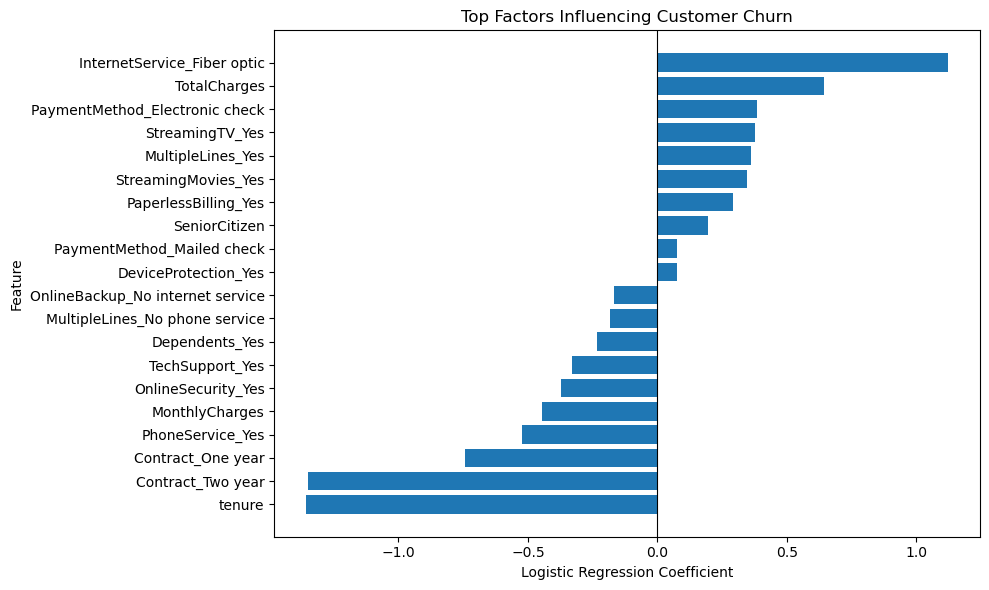

In [43]:
#plotting horizontal bar chart
plt.figure(figsize=(10, 6))
plt.barh(top_features['Feature'], top_features['Coefficient'])
plt.axvline(0, color='black', linewidth=0.8)
plt.title('Top Factors Influencing Customer Churn')
plt.xlabel('Logistic Regression Coefficient')
plt.ylabel('Feature')
plt.tight_layout()
plt.show()

## Part 3: Decision Trees and Overfitting Analysis

In [47]:
#Unconstrained Decision Tree (Entropy)
#Train the model
dt_unconstrained = DecisionTreeClassifier(
    criterion='entropy',
    random_state=42
)

dt_unconstrained.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', random_state=42)

In [48]:
#Evaluate accuracy
train_acc_unconstrained = accuracy_score(
    y_train, dt_unconstrained.predict(X_train)
)

test_acc_unconstrained = accuracy_score(
    y_test, dt_unconstrained.predict(X_test)
)

print("Unconstrained DT - Training Accuracy:", train_acc_unconstrained)
print("Unconstrained DT - Testing Accuracy :", test_acc_unconstrained)

Unconstrained DT - Training Accuracy: 0.9987555555555555
Unconstrained DT - Testing Accuracy : 0.7277896233120114


In [49]:
#Pruned Decision Tree (Controlled Complexity)
#Train pruned tree
dt_pruned = DecisionTreeClassifier(
    criterion='entropy',
    max_depth=5,
    min_samples_leaf=20,
    random_state=42
)

dt_pruned.fit(X_train, y_train)

DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_leaf=20,
                       random_state=42)

In [50]:
#Evaluate accuracy
train_acc_pruned = accuracy_score(
    y_train, dt_pruned.predict(X_train)
)

test_acc_pruned = accuracy_score(
    y_test, dt_pruned.predict(X_test)
)

print("Pruned DT - Training Accuracy:", train_acc_pruned)
print("Pruned DT - Testing Accuracy :", test_acc_pruned)

Pruned DT - Training Accuracy: 0.7927111111111111
Pruned DT - Testing Accuracy : 0.775408670931059


In [54]:
#comparing
comparison_df = pd.DataFrame({
    'Model': ['Unconstrained Decision Tree', 'Pruned Decision Tree'],
    'Training Accuracy': [
        train_acc_unconstrained,
        train_acc_pruned
    ],
    'Testing Accuracy': [
        test_acc_unconstrained,
        test_acc_pruned
    ]
})

comparison_df

,Model,Training Accuracy,Testing Accuracy
0,Unconstrained Decision Tree,0.998756,0.727790
1,Pruned Decision Tree,0.792711,0.775409


The unconstrained decision tree achieves near-perfect training accuracy, indicating it has learned the training data very closely. However, its lower test accuracy suggests overfitting. In contrast, the pruned decision tree, constrained by maximum depth and minimum leaf size, shows slightly lower training accuracy but improved generalization performance on the test data. This demonstrates that controlling model complexity helps reduce overfitting and improves the model’s ability to generalize to unseen data.

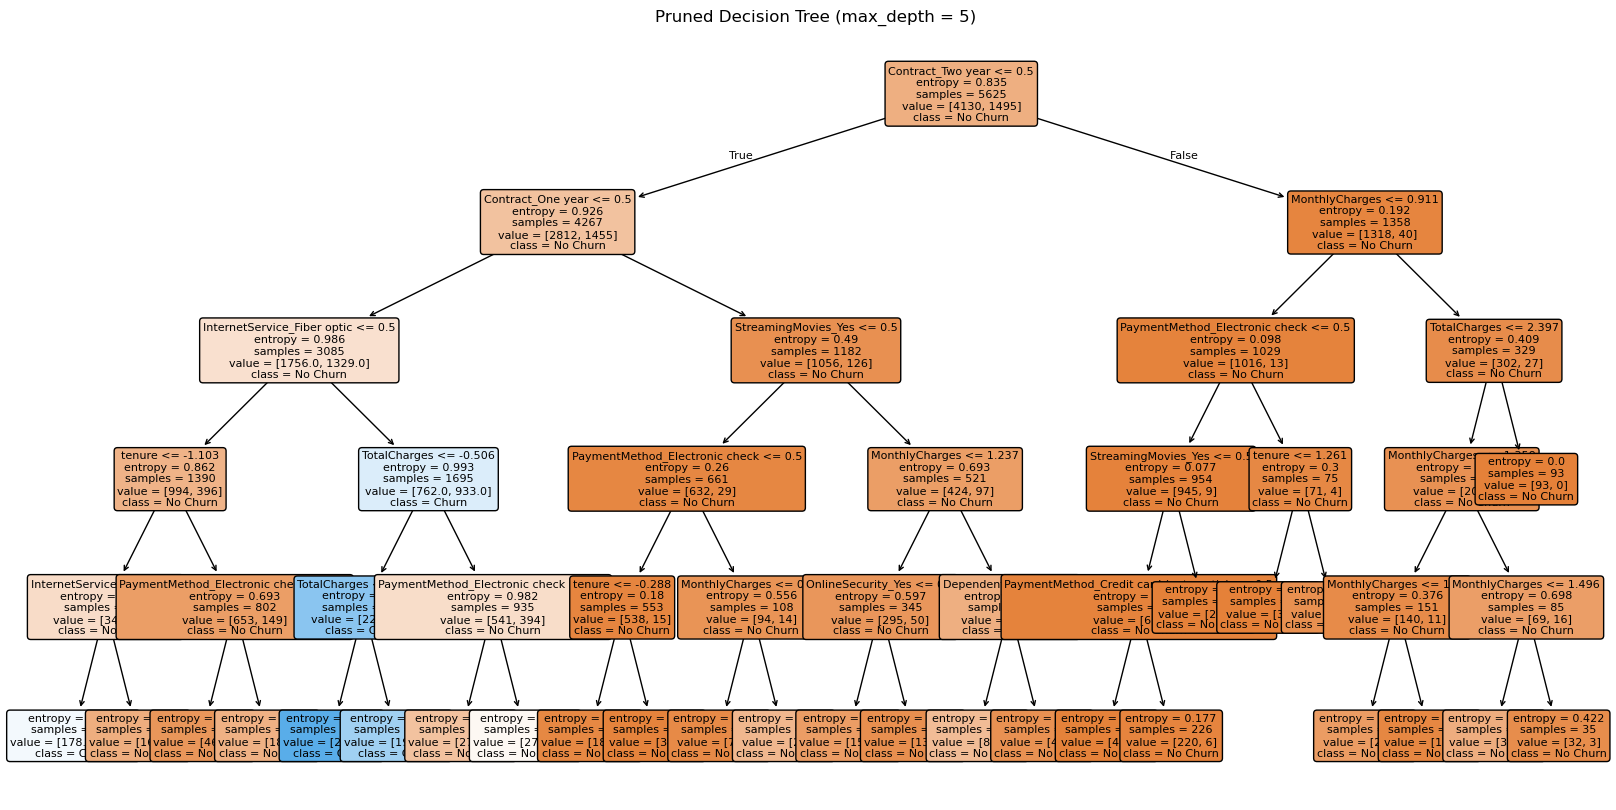

In [52]:
#Visualize the Pruned Decision Tree
plt.figure(figsize=(20, 10))

plot_tree(
    dt_pruned,
    feature_names=X_train.columns,
    class_names=['No Churn', 'Churn'],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.title("Pruned Decision Tree (max_depth = 5)")
plt.show()

The pruned decision tree reveals that contract type is the most critical predictor, with two-year contracts strongly associated with lower churn. For customers without long-term contracts, internet service type (Fiber optic) and payment method become important secondary factors. On the right branch, monthly charges and total charges are key predictors, suggesting that customers with higher bills (without contract protection) face elevated churn risk. Features like streaming services, online security, and dependents appear at deeper levels, indicating moderate predictive value.The left branch explores risk factors (shorter contracts, fiber optic, electronic payments) while the right branch identifies stable customers (long contracts or reasonable charges).

## Part 4: Ensemble Learning (Bagging and Boosting)

To improve predictive performance beyond a single decision tree, ensemble methods were employed. A Random Forest classifier was trained using 100 decision trees to implement bagging, reducing variance and enhancing stability. Additionally, an XGBoost classifier was trained using gradient boosting with logarithmic loss as the evaluation metric. Both ensemble models were fitted on the training data and prepared for comparative evaluation in the next phase.

In [57]:
#Bagging: Random Forest Classifier
#Train Random Forest (100 Trees)
rf_model = RandomForestClassifier(
    n_estimators=100,
    criterion='entropy',
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

RandomForestClassifier(criterion='entropy', n_jobs=-1, random_state=42)

Random Forest uses bagging (bootstrap aggregation) by training multiple decision trees on random subsets of the data and features, then averaging their predictions. This reduces variance and overfitting compared to a single decision tree.

In [63]:
#Boosting: XGBoost Classifier
from xgboost import XGBClassifier
print("XGBoost imported successfully!")

XGBoost imported successfully!


In [66]:
#Train XGBoost Classifier (Log Loss)
from xgboost import XGBClassifier

xgb_model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(X_train, y_train)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=5, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

Boosting builds models sequentially, where each new model focuses on correcting errors made by previous models. XGBoost is an optimized gradient boosting algorithm known for high performance and regularization.

## Part 5: Model Evaluation and Comparison

In [68]:
#Generate predictions for all models

# Logistic Regression
y_pred_lr = log_reg.predict(X_test)

# Pruned Decision Tree
y_pred_dt = dt_pruned.predict(X_test)

# Random Forest
y_pred_rf = rf_model.predict(X_test)

# XGBoost
y_pred_xgb = xgb_model.predict(X_test)


In [75]:
#Calculate evaluation metrics

# Function to compute metrics
def compute_metrics(y_true, y_pred):
    return {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision': precision_score(y_true, y_pred),
        'Recall': recall_score(y_true, y_pred),
        'F1-Score': f1_score(y_true, y_pred)
    }

# Compile metrics for all models
metrics = {
    'Logistic Regression': compute_metrics(y_test, y_pred_lr),
    'Pruned Decision Tree': compute_metrics(y_test, y_pred_dt),
    'Random Forest': compute_metrics(y_test, y_pred_rf),
    'XGBoost': compute_metrics(y_test, y_pred_xgb)
}

# Convert to DataFrame for comparison
metrics_df = pd.DataFrame(metrics).T
metrics_df

,Accuracy,Precision,Recall,F1-Score
Logistic Regression,0.804549,0.650456,0.572193,0.608819
Pruned Decision Tree,0.775409,0.597973,0.473262,0.528358
Random Forest,0.789623,0.632653,0.497326,0.556886
XGBoost,0.790334,0.619335,0.548128,0.581560


In [70]:
#Identifying model with highest recall
best_model_name = metrics_df['Recall'].idxmax()
print("Model with highest Recall:", best_model_name)

Model with highest Recall: Logistic Regression


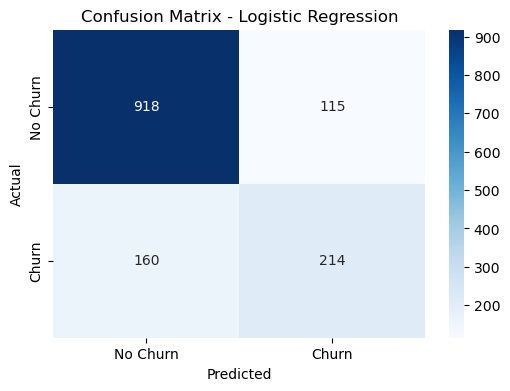

In [71]:
#Confusion Matrix for the best Recall model

# Select predictions
if best_model_name == 'Logistic Regression':
    y_best_pred = y_pred_lr
elif best_model_name == 'Pruned Decision Tree':
    y_best_pred = y_pred_dt
elif best_model_name == 'Random Forest':
    y_best_pred = y_pred_rf
else:
    y_best_pred = y_pred_xgb

# Compute confusion matrix
cm = confusion_matrix(y_test, y_best_pred)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=['No Churn', 'Churn'], yticklabels=['No Churn', 'Churn'])
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title(f'Confusion Matrix - {best_model_name}')
plt.show()


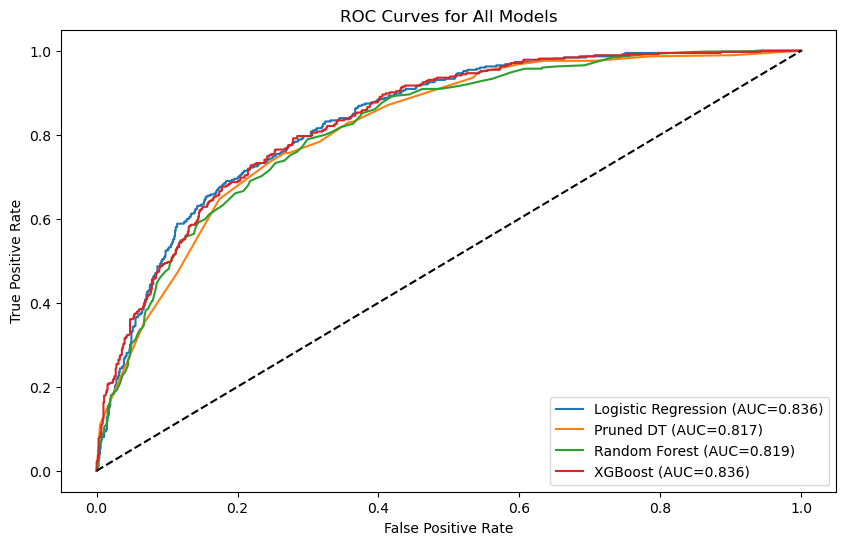

In [72]:
#ROC Curves and AUC for all models

plt.figure(figsize=(10,6))

# Logistic Regression
y_prob_lr = log_reg.predict_proba(X_test)[:,1]
fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
auc_lr = roc_auc_score(y_test, y_prob_lr)
plt.plot(fpr_lr, tpr_lr, label=f'Logistic Regression (AUC={auc_lr:.3f})')

# Pruned Decision Tree
y_prob_dt = dt_pruned.predict_proba(X_test)[:,1]
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)
auc_dt = roc_auc_score(y_test, y_prob_dt)
plt.plot(fpr_dt, tpr_dt, label=f'Pruned DT (AUC={auc_dt:.3f})')

# Random Forest
y_prob_rf = rf_model.predict_proba(X_test)[:,1]
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_prob_rf)
auc_rf = roc_auc_score(y_test, y_prob_rf)
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC={auc_rf:.3f})')

# XGBoost
y_prob_xgb = xgb_model.predict_proba(X_test)[:,1]
fpr_xgb, tpr_xgb, _ = roc_curve(y_test, y_prob_xgb)
auc_xgb = roc_auc_score(y_test, y_prob_xgb)
plt.plot(fpr_xgb, tpr_xgb, label=f'XGBoost (AUC={auc_xgb:.3f})')

# Plot formatting
plt.plot([0,1],[0,1],'k--')  # diagonal
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves for All Models')
plt.legend()
plt.show()

Logistic Regression emerges as the best model for churn prediction given the business context where missing churners is more costly. With a Recall of 0.572, it identifies 57% of actual churners - the highest among all models. While it has 115 false positives, this is acceptable compared to avoiding 160 missed churners. The ROC-AUC of 0.836 (tied with XGBoost) confirms strong discrimination capability. XGBoost is a close second with similar AUC but slightly lower Recall (0.548), making Logistic Regression the optimal choice for this imbalanced cost scenario.